In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = "../data_collection/"
df = pd.read_csv(BASE_PATH + "prep_amazon_delivery_1.csv")

In [3]:
from Univariate import Univariate
obj = Univariate()

quan, qual = obj.quanQual(df)
table = obj.frequency_table(df, 'Delivery_Duration')

table

,Frequency,RelativeFrequency,CumulativeFrequency
Delivery_Duration,,,
10,32,0.000733,32
11,48,0.001100,80
12,44,0.001008,124
13,42,0.000962,166
14,49,0.001123,215
...,...,...,...
250,63,0.001443,43331
255,84,0.001924,43415
260,69,0.001581,43484


In [4]:
descriptive = obj.descriptiveTable(df, ["distance_km", "Delivery_Duration", "Agent_Rating", "hour"])
descriptive

,distance_km,Delivery_Duration,Agent_Rating,hour
Mean,27.255432,124.914475,4.635367,17.425976
Median,9.220419,125.0,4.7,19.0
Mode,20.44293,130,4.7,21
Q1:25%,4.663432,90.0,4.5,15.0
Q2:50%,9.220419,125.0,4.7,19.0
Q3:75%,13.682165,160.0,4.9,21.0
Q4:100%,6884.726399,270.0,5.0,23.0
IQR,9.018732,70.0,0.4,6.0
1.5rule,13.528099,105.0,0.6,9.0
Lesser,-8.864666,-15.0,3.9,6.0


In [5]:
lesser,greater = Univariate.findingOutlier(["distance_km", "Delivery_Duration", "Agent_Rating", "hour"], descriptive)
print(lesser)
print(greater)

Greater Outlier present in  distance_km
Greater Outlier present in  Delivery_Duration
Lesser Outlier present in  Agent_Rating
Lesser Outlier present in  hour
['Agent_Rating', 'hour']
['distance_km', 'Delivery_Duration']


In [6]:
df = Univariate.replacingOutlier(df, descriptive, lesser, greater)

/Users/NYL9BJV/AI-Learning-Journey/my-ai-learning-lab/ml-ds-capstone-project/eda/Univariate.py:97: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset[columnName][dataset[columnName] < descriptive[columnName]["Lesser"]] =  descriptive[colu

In [7]:
descriptive = obj.descriptiveTable(df, ["distance_km", "Delivery_Duration", "Agent_Rating", "hour"])
descriptive

,distance_km,Delivery_Duration,Agent_Rating,hour
Mean,9.795927,124.905425,4.645271,17.484948
Median,9.220419,125.0,4.7,19.0
Mode,20.44293,130,4.7,21
Q1:25%,4.663432,90.0,4.5,15.0
Q2:50%,9.220419,125.0,4.7,19.0
Q3:75%,13.682165,160.0,4.9,21.0
Q4:100%,27.210263,265.0,5.0,23.0
IQR,9.018732,70.0,0.4,6.0
1.5rule,13.528099,105.0,0.6,9.0
Lesser,-8.864666,-15.0,3.9,6.0


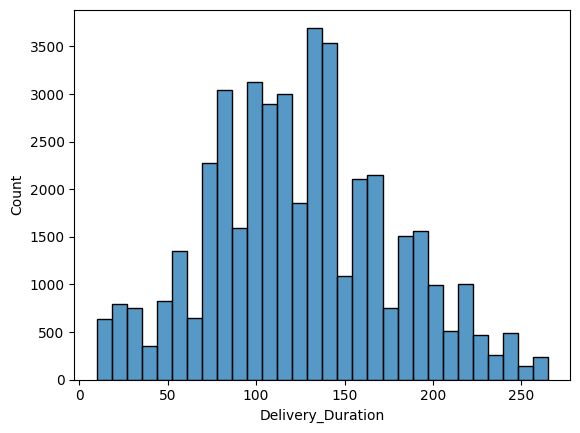

In [8]:
sns.histplot(df["Delivery_Duration"], bins=30)
plt.show()

<Axes: xlabel='Delivery_Duration'>

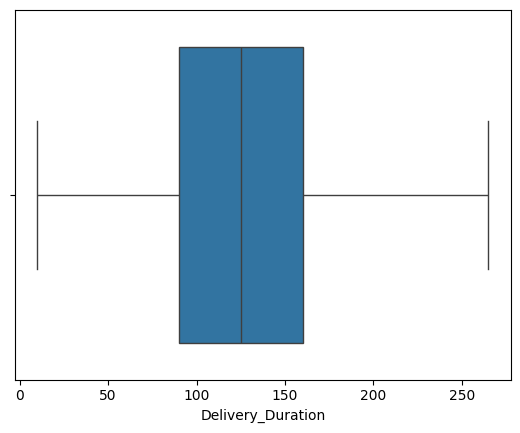

In [9]:
sns.boxplot(x=df["Delivery_Duration"])

<Axes: xlabel='Traffic', ylabel='count'>

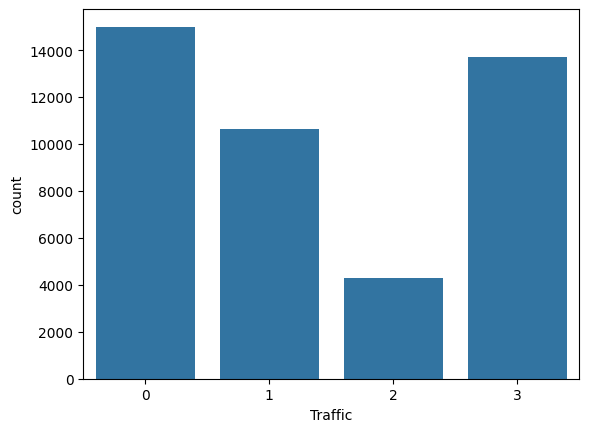

In [10]:
sns.countplot(x=df["Traffic"])

/var/folders/wm/tk7xmnmd1ng4ttzxlqz0bjnw0000gq/T/ipykernel_70793/2318642020.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Delivery_Duration"])


<Axes: xlabel='Delivery_Duration', ylabel='Density'>

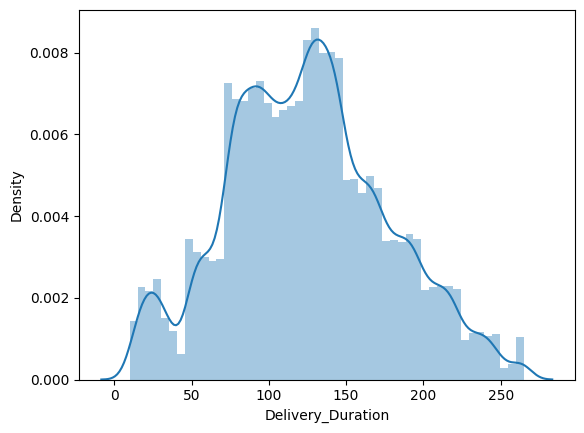

In [11]:
sns.distplot(df["Delivery_Duration"])

/var/folders/wm/tk7xmnmd1ng4ttzxlqz0bjnw0000gq/T/ipykernel_70793/1530054922.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["distance_km"])


<Axes: xlabel='distance_km', ylabel='Density'>

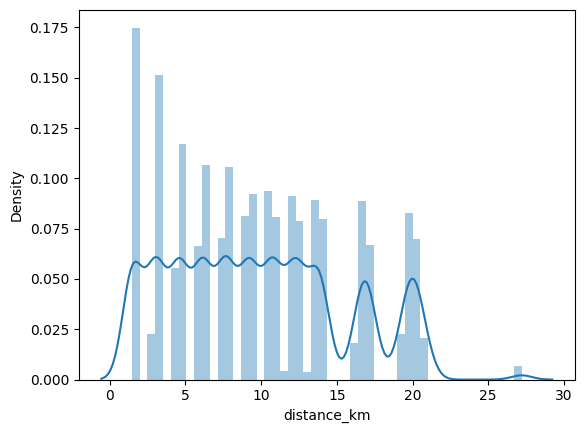

In [12]:
sns.distplot(df["distance_km"])

<Axes: xlabel='Agent_Age', ylabel='count'>

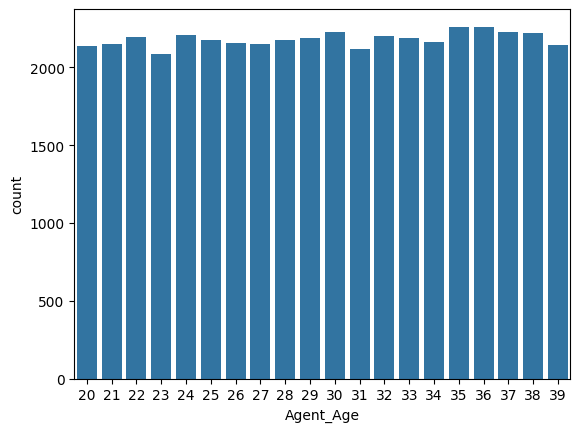

In [13]:
sns.countplot(x=df["Agent_Age"])

In [14]:
Univariate.get_pdf_probability(dataset["Delivery_Duration"],60,180)

NameError: name 'dataset' is not defined